In [10]:
from sklearn.datasets import make_classification
import pandas as pd

X, y = make_classification(
    n_samples=1000,
    n_features=35,
    n_informative=20,
    n_classes=2,
    random_state=42
)

df = pd.DataFrame(X)
df['Gender'] = y
df.head()
X = df.drop("Gender", axis=1)
y = df["Gender"]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.decomposition import PCA

pca = PCA(n_components=8)
X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5, weights='distance')
model.fit(X_train, y_train)
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
import numpy as np

importance = np.abs(pca.components_).sum(axis=0)

print("Feature Importance (approx):")
print(importance)

Shape after PCA: (1000, 8)
Accuracy: 0.795
Confusion Matrix:
 [[77 23]
 [18 82]]
Feature Importance (approx):
[1.34148151 1.24348515 0.57439458 1.52213491 0.70627951 1.06336752
 1.48748618 0.23611    1.31219786 1.09420834 1.17424803 1.25166318
 1.22874335 1.23021985 1.36557192 1.39178973 0.39130491 0.55982992
 0.38225074 0.76033292 0.35340612 1.31179612 0.678086   1.53751507
 0.39960604 1.43592261 0.4733352  1.37614461 1.61416204 1.36132425
 0.49904868 0.84800493 1.25529222 1.33218262 1.29002443]


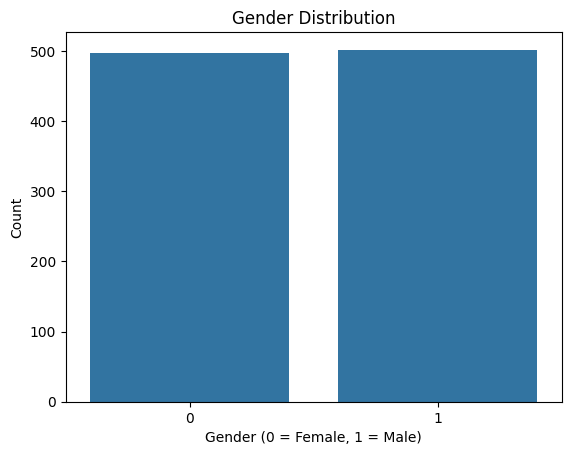

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Gender Distribution")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()

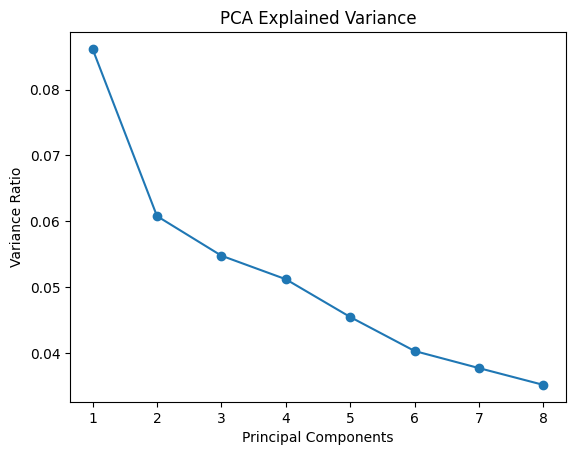

In [13]:
plt.plot(range(1, 9), pca.explained_variance_ratio_, marker='o')
plt.title("PCA Explained Variance")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.show()

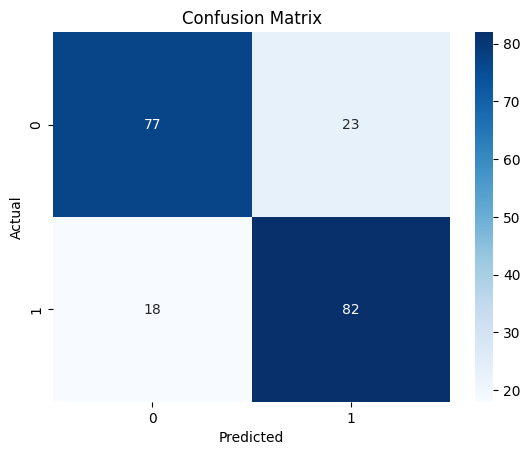

In [14]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

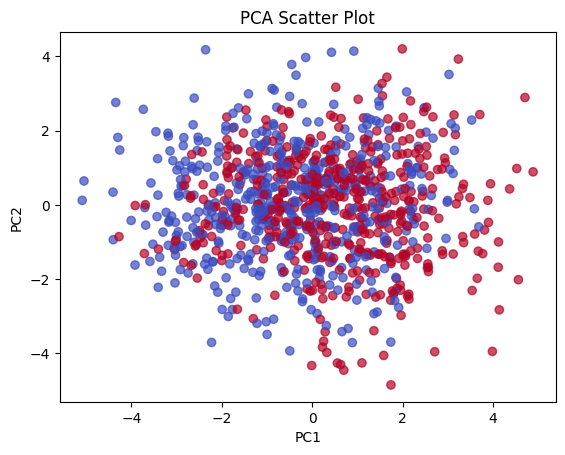

In [15]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.title("PCA Scatter Plot")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


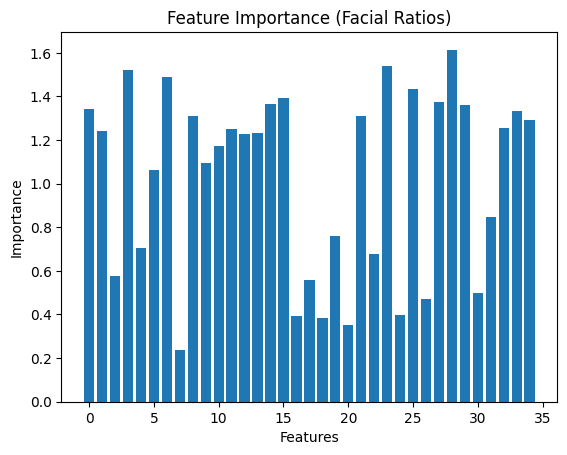

In [16]:
import numpy as np

importance = np.abs(pca.components_).sum(axis=0)

plt.bar(range(len(importance)), importance)
plt.title("Feature Importance (Facial Ratios)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 36 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1000 non-null   float64
 1   1       1000 non-null   float64
 2   2       1000 non-null   float64
 3   3       1000 non-null   float64
 4   4       1000 non-null   float64
 5   5       1000 non-null   float64
 6   6       1000 non-null   float64
 7   7       1000 non-null   float64
 8   8       1000 non-null   float64
 9   9       1000 non-null   float64
 10  10      1000 non-null   float64
 11  11      1000 non-null   float64
 12  12      1000 non-null   float64
 13  13      1000 non-null   float64
 14  14      1000 non-null   float64
 15  15      1000 non-null   float64
 16  16      1000 non-null   float64
 17  17      1000 non-null   float64
 18  18      1000 non-null   float64
 19  19      1000 non-null   float64
 20  20      1000 non-null   float64
 21  21      1000 non-null   float64
 22  2

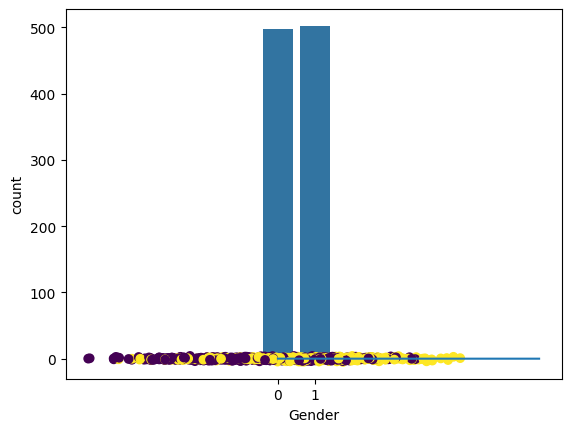

In [17]:
df.head()
df.info()
df.describe()
sns.countplot(x=y)
plt.plot(pca.explained_variance_ratio_)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)